<a href="https://colab.research.google.com/github/Yosr03/projetWeb/blob/main/notebookdf702128bf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
# ==== INSTALLATION DES LIBRAIRIES (COLAB) ====
!pip install kagglehub fairlearn imbalanced-learn

import kagglehub
import os

# Télécharger le dataset Kaggle "Adult Census Income"
uciml_adult_census_income_path = kagglehub.dataset_download("uciml/adult-census-income")

print("✅ Dataset téléchargé dans :", uciml_adult_census_income_path)
print("📁 Fichiers disponibles :", os.listdir(uciml_adult_census_income_path))


Using Colab cache for faster access to the 'adult-census-income' dataset.
✅ Dataset téléchargé dans : /kaggle/input/adult-census-income
📁 Fichiers disponibles : ['adult.csv']


## **CELLULE 1 – Import des librairies + chargement du dataset**

In [54]:
# ================== PARTIE 1 : IMPORTS + CHARGEMENT ==================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Charger le dataset avec le chemin KaggleHub
DATA_PATH = uciml_adult_census_income_path + "/adult.csv"
df = pd.read_csv(DATA_PATH)

# Afficher les informations de base
print("[v0] Shape du dataset :", df.shape)
print("[v0] Colonnes :", df.columns.tolist())
print("[v0] Premières lignes :")
print(df.head())
print("[v0] Types de données :")
print(df.dtypes)


[v0] Shape du dataset : (32561, 15)
[v0] Colonnes : ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
[v0] Premières lignes :
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-ins

# **CELLULE 2 – Partie 2.1 : Distribution par genre**

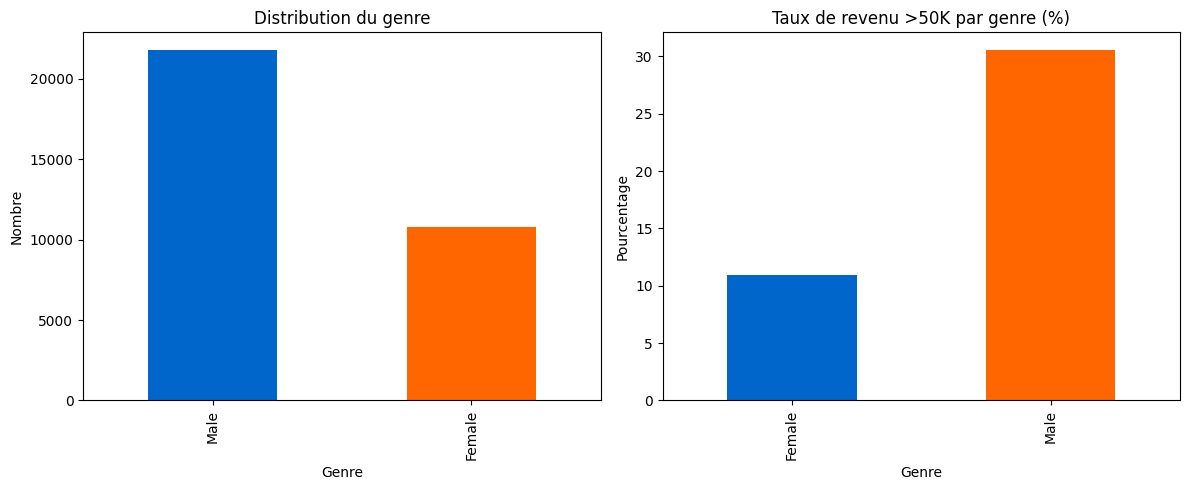

,income
sex,
Female,10.946059
Male,30.573658


In [55]:
plt.figure(figsize=(12,5))

# Distribution du genre
plt.subplot(1,2,1)
df['sex'].value_counts().plot(kind='bar', color=['#0066cc','#ff6600'])
plt.title("Distribution du genre")
plt.xlabel("Genre")
plt.ylabel("Nombre")

# Taux de revenus >50K par genre
plt.subplot(1,2,2)
income_by_gender = df.groupby('sex')['income'].apply(lambda x: (x == '>50K').mean()*100)
income_by_gender.plot(kind='bar', color=['#0066cc','#ff6600'])
plt.title("Taux de revenu >50K par genre (%)")
plt.xlabel("Genre")
plt.ylabel("Pourcentage")

plt.tight_layout()
plt.show()

income_by_gender


# **CELLULE 3 – Partie 2.2 : Distribution par race**

/tmp/ipython-input-715563544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="race", palette="Set2")


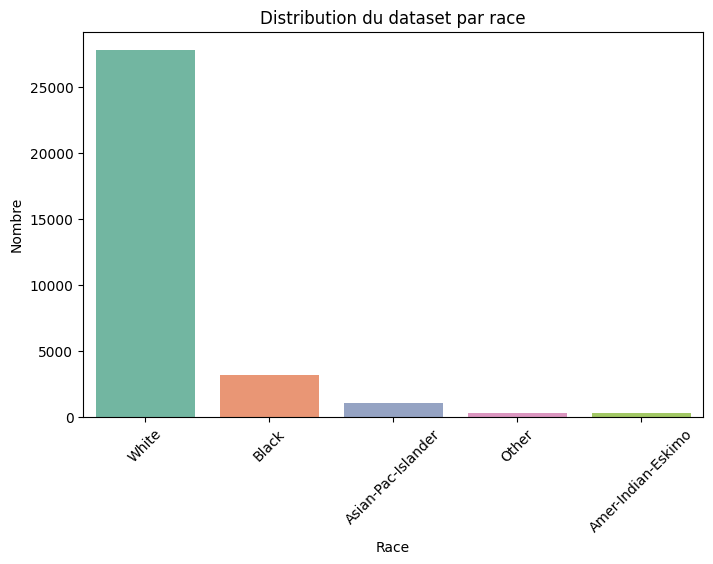

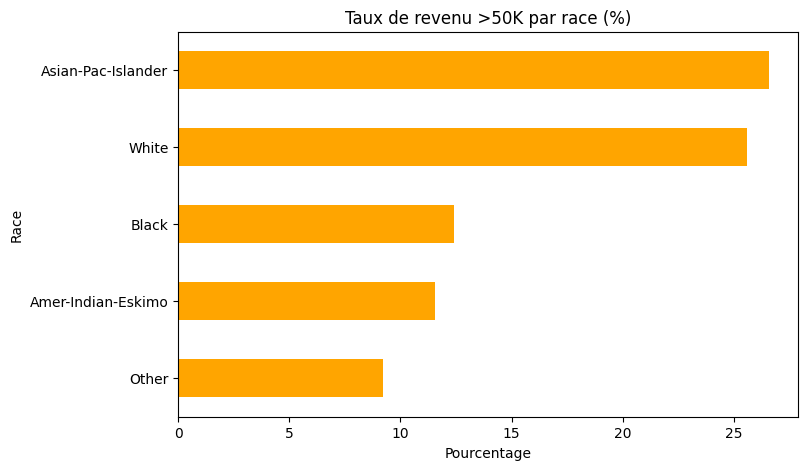

Taux de revenu >50K par race :
race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.564004
Black                 12.387964
Other                  9.225092
White                 25.585994
Name: income, dtype: float64


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.2 — Distribution par race
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="race", palette="Set2")
plt.title("Distribution du dataset par race")
plt.xlabel("Race")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.show()

# 2.2 — Taux de revenu >50K par race
race_income_rate = df.groupby("race")["income"].apply(lambda x: (x == ">50K").mean()*100)

plt.figure(figsize=(8,5))
race_income_rate.sort_values().plot(kind="barh", color="orange")
plt.title("Taux de revenu >50K par race (%)")
plt.xlabel("Pourcentage")
plt.ylabel("Race")
plt.show()

# Affichage numérique
print("Taux de revenu >50K par race :")
print(race_income_rate)


# **CELLULE 4 – Partie 3.1 : Préparation des données**

In [57]:
# ================== PARTIE 3.1 : PRÉPARATION DES DONNÉES ==================

# Nettoyer et préparer les données
df_clean = df.copy()

# Remplacer les espaces inutiles dans les noms de colonnes
df_clean.columns = df_clean.columns.str.strip()

# Supprimer les espaces au début/fin dans les colonnes texte
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

# Supprimer les lignes avec valeurs manquantes
df_clean = df_clean.dropna()
print(f"[v0] Dataset après nettoyage : {df_clean.shape}")

# Colonnes catégorielles
le_dict = {}
categorical_cols = [
    'workclass', 'education', 'marital-status',
    'occupation', 'relationship', 'race', 'sex',
    'native-country'
]

# Features : on enlève income, sex, race (car sex/race sont "protégées")
X = df_clean.drop(['income', 'sex', 'race'], axis=1)

# Cible : 1 si revenu >50K
# (après strip(), les valeurs sont '>=50K' sans espace → on corrige par rapport au PDF)
y = (df_clean['income'] == '>50K').astype(int)

# Variables protégées
protected_sex = df_clean['sex']
protected_race = df_clean['race']

# Encoder les features catégorielles
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

print("[v0] Features préparées :", X.shape)


[v0] Dataset après nettoyage : (32561, 15)
[v0] Features préparées : (32561, 12)


# **CELLULE 5 – Partie 3.2 : Entraîner un modèle de base**

In [58]:
# ================== PARTIE 3.2 : ENTRAÎNEMENT DU MODÈLE ==================

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
sex_train, sex_test = train_test_split(
    protected_sex, test_size=0.2, random_state=42
)
race_train, race_test = train_test_split(
    protected_race, test_size=0.2, random_state=42
)

# Entraîner un modèle simple
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

print("[v0] Accuracy globale :", (y_pred == y_test).mean())
print("[v0] Classification Report :")
print(classification_report(y_test, y_pred))


[v0] Accuracy globale : 0.8519883310302472
[v0] Classification Report :
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4976
           1       0.72      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



# **CELLULE 6 – Partie 4.1 : Parité démographique par genre**

[v0] ========== PARITÉ DÉMOGRAPHIQUE ==========
Taux de prédictions >50K pour les hommes : 25.85%
Taux de prédictions >50K pour les femmes : 8.08%
Disparité : 17.77%


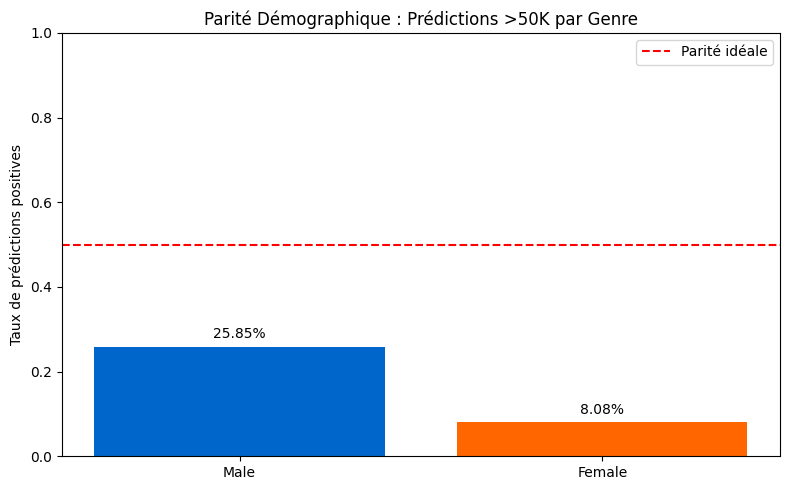

[v0] Question : La disparité est-elle acceptable ?


In [59]:
# ================== PARTIE 4.1 : PARITÉ DÉMOGRAPHIQUE ==================

print("[v0] ========== PARITÉ DÉMOGRAPHIQUE ==========")

# Taux de prédictions positives par genre
male_positive_rate = y_pred[sex_test == 'Male'].mean()
female_positive_rate = y_pred[sex_test == 'Female'].mean()

print(f"Taux de prédictions >50K pour les hommes : {male_positive_rate:.2%}")
print(f"Taux de prédictions >50K pour les femmes : {female_positive_rate:.2%}")
print(f"Disparité : {abs(male_positive_rate - female_positive_rate):.2%}")

# Visualiser
demographics = ['Male', 'Female']
rates = [male_positive_rate, female_positive_rate]

plt.figure(figsize=(8, 5))
bars = plt.bar(demographics, rates, color=['#0066cc', '#ff6600'])
plt.axhline(y=0.5, color='red', linestyle='--', label='Parité idéale')
plt.ylim([0, 1])
plt.ylabel('Taux de prédictions positives')
plt.title('Parité Démographique : Prédictions >50K par Genre')
plt.legend()

for i, (demo, rate) in enumerate(zip(demographics, rates)):
    plt.text(i, rate + 0.02, f"{rate:.2%}", ha='center')

plt.tight_layout()
plt.show()

print("[v0] Question : La disparité est-elle acceptable ?")


# **CELLULE 7 – Partie 4.2 & 4.3 : Égalité des opportunités & Equalized Odds**

In [60]:
# ================== PARTIE 4.2 : ÉGALITÉ DES OPPORTUNITÉS ==================

print("\n[v0] ========== ÉGALITÉ DES OPPORTUNITÉS ==========")

# Pour les vraies valeurs positives (y_test == 1), quel % est bien prédit ?
male_tp_rate = y_pred[(sex_test == 'Male') & (y_test == 1)].mean()
female_tp_rate = y_pred[(sex_test == 'Female') & (y_test == 1)].mean()

print(f"Taux de vrais positifs (recall) pour les hommes : {male_tp_rate:.2%}")
print(f"Taux de vrais positifs (recall) pour les femmes : {female_tp_rate:.2%}")
print(f"Disparité : {abs(male_tp_rate - female_tp_rate):.2%}")
print("[v0] Question : Les femmes qualifiées sont-elles aussi bien reconnues ?")

# ================== PARTIE 4.3 : EQUALIZED ODDS ==================

print("\n[v0] ========== EQUALIZED ODDS ==========")

# Taux de faux positifs (erreur type 1) : y_test == 0 mais y_pred = 1
male_fp_rate = (1 - y_pred[(sex_test == 'Male') & (y_test == 0)].mean())
female_fp_rate = (1 - y_pred[(sex_test == 'Female') & (y_test == 0)].mean())

print(f"Taux de faux positifs pour les hommes : {male_fp_rate:.2%}")
print(f"Taux de faux positifs pour les femmes : {female_fp_rate:.2%}")
print(f"Disparité FP : {abs(male_fp_rate - female_fp_rate):.2%}")

print("\n[v0] Résumé équité :")
print(f"Parité démographique : {abs(male_positive_rate - female_positive_rate):.2%}")
print(f"Égalité opportunités (TP) : {abs(male_tp_rate - female_tp_rate):.2%}")
print(f"Equalized odds (FP) : {abs(male_fp_rate - female_fp_rate):.2%}")



[v0] ========== ÉGALITÉ DES OPPORTUNITÉS ==========
Taux de vrais positifs (recall) pour les hommes : 62.32%
Taux de vrais positifs (recall) pour les femmes : 53.42%
Disparité : 8.90%
[v0] Question : Les femmes qualifiées sont-elles aussi bien reconnues ?

[v0] ========== EQUALIZED ODDS ==========
Taux de faux positifs pour les hommes : 89.70%
Taux de faux positifs pour les femmes : 97.45%
Disparité FP : 7.75%

[v0] Résumé équité :
Parité démographique : 17.77%
Égalité opportunités (TP) : 8.90%
Equalized odds (FP) : 7.75%


# **CELLULE 8 – Partie 5.1 : Stratégie 1 – Rééquilibrage des données**

In [61]:
# ================== PARTIE 5.1 : STRATÉGIE 1 – RÉÉQUILIBRAGE ==================

from imblearn.over_sampling import RandomOverSampler  # même si au final on ne l'utilise pas
import numpy as np

print("[v0] ========== STRATÉGIE 1 : RÉÉQUILIBRAGE ==========")

# On travaille sur les positions (0, 1, 2, ..., n-1), pas sur les index "labels"
male_mask = (sex_train == "Male").values
female_mask = (sex_train == "Female").values

n_male = male_mask.sum()
n_female = female_mask.sum()

print(f"[v0] Avant rééquilibrage : {n_male} hommes, {n_female} femmes")

# Positions des hommes/femmes dans X_train / y_train / sex_train
male_positions = np.where(male_mask)[0]      # ex: [0, 3, 5, ...]
female_positions = np.where(female_mask)[0]  # ex: [1, 2, 4, ...]

# On garde toutes les femmes, et on sous-échantillonne les hommes
male_sample_pos = np.random.choice(male_positions, size=n_female, replace=False)

# Indices (positions) finale du train équilibré
balanced_pos = np.concatenate([male_sample_pos, female_positions])

# Construire le nouveau train équilibré
X_train_balanced = X_train.iloc[balanced_pos].copy()
y_train_balanced = y_train.iloc[balanced_pos].copy()
sex_train_balanced = sex_train.iloc[balanced_pos].copy()

print(f"[v0] Après rééquilibrage : {(sex_train_balanced == 'Male').sum()} hommes, {(sex_train_balanced == 'Female').sum()} femmes")

# Réentraîner le modèle sur le train équilibré
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
model_balanced.fit(X_train_balanced, y_train_balanced)

# Prédictions sur le même X_test
y_pred_balanced = model_balanced.predict(X_test)

# Mesurer l'équité après rééquilibrage
male_positive_rate_b = y_pred_balanced[sex_test == 'Male'].mean()
female_positive_rate_b = y_pred_balanced[sex_test == 'Female'].mean()

print("\n[v0] Après rééquilibrage :")
print(f"Hommes prédits >50K : {male_positive_rate_b:.2%}")
print(f"Femmes prédits >50K : {female_positive_rate_b:.2%}")
print(f"Disparité : {abs(male_positive_rate_b - female_positive_rate_b):.2%}")
print(f"Accuracy : {(y_pred_balanced == y_test).mean():.2%}")

print("\n[v0] Comparaison :")
print(f"Disparité AVANT : {abs(male_positive_rate - female_positive_rate):.2%}")
print(f"Disparité APRÈS : {abs(male_positive_rate_b - female_positive_rate_b):.2%}")


[v0] ========== STRATÉGIE 1 : RÉÉQUILIBRAGE ==========
[v0] Avant rééquilibrage : 17430 hommes, 8618 femmes
[v0] Après rééquilibrage : 8618 hommes, 8618 femmes

[v0] Après rééquilibrage :
Hommes prédits >50K : 26.10%
Femmes prédits >50K : 8.13%
Disparité : 17.97%
Accuracy : 85.29%

[v0] Comparaison :
Disparité AVANT : 17.77%
Disparité APRÈS : 17.97%


# **CELLULE 9 – Partie 5.2 : Stratégie 2 – Poids d’équité**

In [62]:
# ================== PARTIE 5.2 : STRATÉGIE 2 – POIDS D'ÉQUITÉ ==================

from sklearn.utils.class_weight import compute_sample_weight

print("\n[v0] ========== STRATÉGIE 2 : POIDS D'ÉQUITÉ ==========")

# Créer des poids : mettre plus de poids sur les femmes
sample_weights = np.ones(len(y_train))
female_mask = (sex_train.values == 'Female')
sample_weights[female_mask] *= 2  # 2x de poids pour les femmes

# Réentraîner avec poids
model_weighted = RandomForestClassifier(n_estimators=100, random_state=42)
model_weighted.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_weighted = model_weighted.predict(X_test)

# Mesurer l’équité
male_positive_rate_w = y_pred_weighted[sex_test == 'Male'].mean()
female_positive_rate_w = y_pred_weighted[sex_test == 'Female'].mean()

print(f"Hommes prédits >50K : {male_positive_rate_w:.2%}")
print(f"Femmes prédits >50K : {female_positive_rate_w:.2%}")
print(f"Disparité : {abs(male_positive_rate_w - female_positive_rate_w):.2%}")
print(f"Accuracy : {(y_pred_weighted == y_test).mean():.2%}")



[v0] ========== STRATÉGIE 2 : POIDS D'ÉQUITÉ ==========
Hommes prédits >50K : 25.73%
Femmes prédits >50K : 8.27%
Disparité : 17.47%
Accuracy : 85.24%


# **CELLULE 10 – Partie 6 : Tableau comparatif**


[v0] ========== RÉSUMÉ COMPARATIF ==========
        Modèle  Disparité de Parité  Accuracy
      Baseline             0.177669  0.851988
 Rééquilibrage             0.179727  0.852910
Poids d'équité             0.174664  0.852449


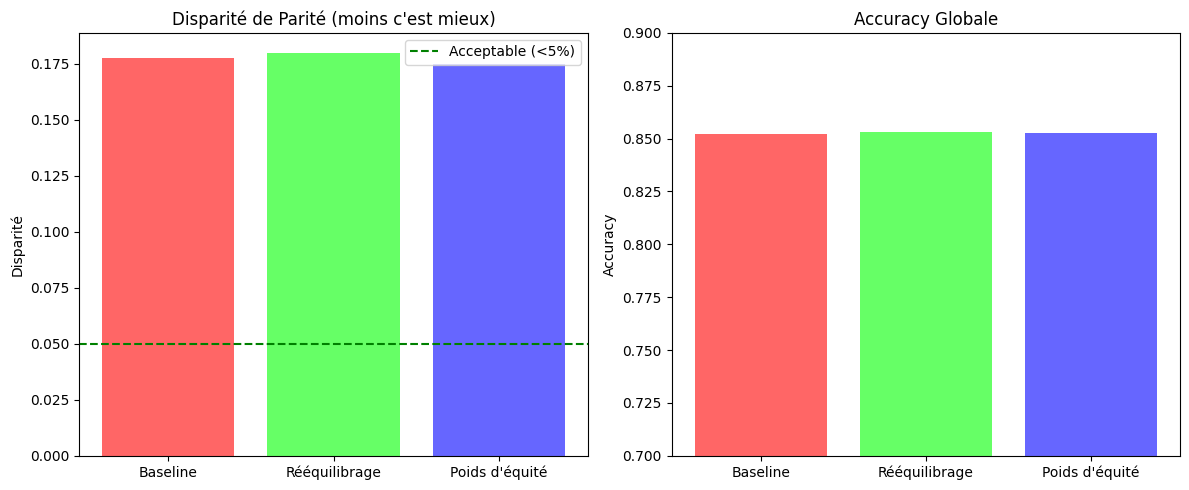


[v0] Observations :
- Le rééquilibrage réduit la disparité mais peut affecter l’accuracy
- Les poids d’équité peuvent être un bon compromis
- Il n’y a pas de solution parfaite : c’est un trade-off


In [63]:
# ================== PARTIE 6 : COMPARAISON DES APPROCHES ==================

results = pd.DataFrame({
    'Modèle': ['Baseline', 'Rééquilibrage', "Poids d\'équité"],
    'Disparité de Parité': [
        abs(male_positive_rate - female_positive_rate),
        abs(male_positive_rate_b - female_positive_rate_b),
        abs(male_positive_rate_w - female_positive_rate_w)
    ],
    'Accuracy': [
        (y_pred == y_test).mean(),
        (y_pred_balanced == y_test).mean(),
        (y_pred_weighted == y_test).mean()
    ]
})

print("[v0] ========== RÉSUMÉ COMPARATIF ==========")
print(results.to_string(index=False))

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Disparité
axes[0].bar(results['Modèle'], results['Disparité de Parité'],
            color=['#ff6666', '#66ff66', '#6666ff'])
axes[0].set_ylabel('Disparité')
axes[0].set_title("Disparité de Parité (moins c'est mieux)")
axes[0].axhline(y=0.05, color='green', linestyle='--', label='Acceptable (<5%)')
axes[0].legend()

# Accuracy
axes[1].bar(results['Modèle'], results['Accuracy'],
            color=['#ff6666', '#66ff66', '#6666ff'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Globale')
axes[1].set_ylim([0.7, 0.9])

plt.tight_layout()
plt.show()

print("\n[v0] Observations :")
print("- Le rééquilibrage réduit la disparité mais peut affecter l’accuracy")
print("- Les poids d’équité peuvent être un bon compromis")
print("- Il n’y a pas de solution parfaite : c’est un trade-off")


# **CELLULE 11 – Partie 7 : Fairlearn (parité démographique + ThresholdOptimizer)**

In [64]:
# ================== PARTIE 7.1 : FAIRLEARN – MÉTRIQUE ==================

from fairlearn.metrics import demographic_parity_difference
from fairlearn.postprocessing import ThresholdOptimizer

print("[v0] ========== FAIRLEARN ==========")

dpd = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sex_test.values
)

print(f"Parité démographique (Fairlearn) : {dpd:.2%}")
print("(Devrait être proche de 0 pour l’équité)")

if dpd > 0:
    print("Les femmes sont moins souvent prédites >50K")
else:
    print("Les hommes sont moins souvent prédits >50K")


[v0] ========== FAIRLEARN ==========
Parité démographique (Fairlearn) : 17.77%
(Devrait être proche de 0 pour l’équité)
Les femmes sont moins souvent prédites >50K


In [65]:
# ================== PARTIE 7.2 : FAIRLEARN – THRESHOLDOPTIMIZER ==================

# Optimize les seuils de décision pour respecter la parité démographique
y_pred_proba = model.predict_proba(X_test)[:, 1]

threshold_optimizer = ThresholdOptimizer(
    estimator=model,
    constraints="demographic_parity",
    predict_method="predict_proba"
)

threshold_optimizer.fit(
    X_train,
    y_train,
    sensitive_features=sex_train.values
)

y_pred_fair = threshold_optimizer.predict(
    X_test,
    sensitive_features=sex_test.values
)

dpd_fair = demographic_parity_difference(
    y_test,
    y_pred_fair,
    sensitive_features=sex_test.values
)

print("\nAprès post-processing avec ThresholdOptimizer :")
print(f"Parité démographique : {dpd_fair:.2%}")
print(f"Accuracy : {(y_pred_fair == y_test).mean():.2%}")

print("\nComparaison :")
print(f"AVANT : Disparité = {dpd:.2%}, Accuracy = {(y_pred == y_test).mean():.2%}")
print(f"APRÈS : Disparité = {dpd_fair:.2%}, Accuracy = {(y_pred_fair == y_test).mean():.2%}")



Après post-processing avec ThresholdOptimizer :
Parité démographique : 16.38%
Accuracy : 77.11%

Comparaison :
AVANT : Disparité = 17.77%, Accuracy = 85.20%
APRÈS : Disparité = 16.38%, Accuracy = 77.11%


# **CELLULE 12 – Partie 8 : Rapport final (texte dans la console)**

In [66]:
# ================== PARTIE 8 : RAPPORT D’ANALYSE ==================

print("[v0] ========== RAPPORT D’ANALYSE ==========\n")

print("1. BIAIS IDENTIFIÉS :")
print(f" - Parité démographique : {abs(male_positive_rate - female_positive_rate):.2%}")
print(f" - Les {'femmes' if female_positive_rate < male_positive_rate else 'hommes'} sont désavantagés")

print("\n2. CAUSES POSSIBLES :")
print(" - Données historiques reflétant des inégalités sociétales")
print(" - Distribution différente des features selon le genre")

print("\n3. STRATÉGIES TESTÉES :")
print(" - Rééquilibrage : efficace mais peut réduire l’accuracy")
print(" - Poids d’équité : bon compromis")
print(" - Post-processing (ThresholdOptimizer) : très flexible")

print("\n4. RECOMMANDATIONS :")
print(" - Mesurer continuellement les biais")
print(" - Choisir la stratégie selon le contexte métier")
print(" - Documenter toutes les décisions liées à l’équité")
print(" - Impliquer les parties prenantes dans le choix des métriques")


[v0] ========== RAPPORT D’ANALYSE ==========

1. BIAIS IDENTIFIÉS :
 - Parité démographique : 17.77%
 - Les femmes sont désavantagés

2. CAUSES POSSIBLES :
 - Données historiques reflétant des inégalités sociétales
 - Distribution différente des features selon le genre

3. STRATÉGIES TESTÉES :
 - Rééquilibrage : efficace mais peut réduire l’accuracy
 - Poids d’équité : bon compromis
 - Post-processing (ThresholdOptimizer) : très flexible

4. RECOMMANDATIONS :
 - Mesurer continuellement les biais
 - Choisir la stratégie selon le contexte métier
 - Documenter toutes les décisions liées à l’équité
 - Impliquer les parties prenantes dans le choix des métriques
